# EDA — Telco Customer Churn

**Tech Challenge Fase 01** · Etapa 1

**Dataset:** Telco Customer Churn (IBM, 7.043 × 21)

**Objetivo:** Avaliar volume, qualidade, distribuição e *data readiness* antes da modelagem (baseline + feature engineering + MLP).

Cada seção tem um achado principal resumido em markdown. A última seção consolida insights e a ponte para a Etapa 2 (Feature Engineering).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

In [2]:
df = pd.read_csv("../src/data/telco_churn.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Volume e Schema

Verificamos dtypes, contagem de valores não-nulos e estatísticas básicas. Telco IBM tem 7.043 linhas × 21 colunas — volume confortável para ML tabular clássico (PDF aceita ≥ 5.000 registros).

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
print("=== Numéricas ===")
display(df.describe())
print("\n=== Categóricas ===")
display(df.describe(include=["object"]))

=== Numéricas ===


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000



=== Categóricas ===


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


## 3. Qualidade dos dados

Pontos críticos a verificar:

- `TotalCharges` vem como **string** (com whitespace para clientes novos).
- `No internet service` / `No phone service` aparecem como categorias separadas — semanticamente equivalentes a `No`.
- Coluna `customerID` é identificador, não feature — deverá ser removida antes da modelagem.

In [5]:
# TotalCharges está como object — investigar
print(f"dtype: {df['TotalCharges'].dtype}")
print("\nValores que falham na conversão para float:")
mask_bad = pd.to_numeric(df["TotalCharges"], errors="coerce").isna()
print(f"  Total: {mask_bad.sum()} ({100*mask_bad.mean():.2f}%)")
df.loc[mask_bad, ["customerID", "tenure", "TotalCharges", "Churn"]].head(10)

dtype: object



Valores que falham na conversão para float:
  Total: 11 (0.16%)


,customerID,tenure,TotalCharges,Churn
488,4472-LVYGI,0,,No
753,3115-CZMZD,0,,No
936,5709-LVOEQ,0,,No
1082,4367-NUYAO,0,,No
1340,1371-DWPAZ,0,,No
3331,7644-OMVMY,0,,No
3826,3213-VVOLG,0,,No
4380,2520-SGTTA,0,,No
5218,2923-ARZLG,0,,No
6670,4075-WKNIU,0,,No


In [6]:
# Convertendo TotalCharges e re-investigando missing
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": (100 * df.isnull().mean()).round(2),
}).query("missing_count > 0").sort_values("missing_pct", ascending=False)
missing

,missing_count,missing_pct
TotalCharges,11,0.16


In [7]:
# Duplicatas (full-row e por customerID)
print(f"Duplicatas full-row: {df.duplicated().sum()}")
print(f"customerID duplicados: {df['customerID'].duplicated().sum()}")

Duplicatas full-row: 0
customerID duplicados: 0


In [8]:
# Mapeando "No internet service" / "No phone service" → "No"
inconsistent_cols = [
    "MultipleLines", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
]
for col in inconsistent_cols:
    print(f"{col}: {df[col].value_counts().to_dict()}")

MultipleLines: {'No': 3390, 'Yes': 2971, 'No phone service': 682}
OnlineSecurity: {'No': 3498, 'Yes': 2019, 'No internet service': 1526}
OnlineBackup: {'No': 3088, 'Yes': 2429, 'No internet service': 1526}
DeviceProtection: {'No': 3095, 'Yes': 2422, 'No internet service': 1526}
TechSupport: {'No': 3473, 'Yes': 2044, 'No internet service': 1526}
StreamingTV: {'No': 2810, 'Yes': 2707, 'No internet service': 1526}
StreamingMovies: {'No': 2785, 'Yes': 2732, 'No internet service': 1526}


## 4. Distribuição da variável target

A target é `Churn` (Yes/No). Esperamos cerca de 26–27% de positivos (dataset IBM clássico). Esse desbalanceamento orienta a escolha de *recall* como métrica primária e `class_weight='balanced'` na Regressão Logística.

In [9]:
counts = df["Churn"].value_counts()
pct = df["Churn"].value_counts(normalize=True) * 100
print(counts.to_string())
print()
print(pct.round(2).astype(str) + " %")

Churn
No     5174
Yes    1869



Churn
No     73.46 %
Yes    26.54 %
Name: proportion, dtype: object


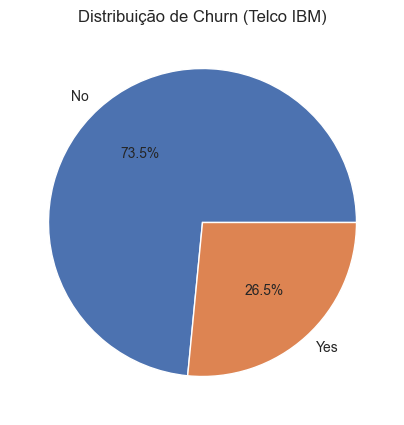

Ratio de balanceamento: 0.36  (ratio < 0.5 ⇒ desbalanceado)


In [10]:
fig, ax = plt.subplots(figsize=(5, 5))
counts.plot(kind="pie", autopct="%.1f%%", colors=["#4C72B0", "#DD8452"], ax=ax)
ax.set_ylabel("")
ax.set_title("Distribuição de Churn (Telco IBM)")
plt.show()
ratio = counts.min() / counts.max()
print(f"Ratio de balanceamento: {ratio:.2f}  (ratio < 0.5 ⇒ desbalanceado)")

## 5. Distribuição univariada

Histogramas para numéricas (`tenure`, `MonthlyCharges`, `TotalCharges`), barplots para categóricas-chave (`Contract`, `PaymentMethod`, `InternetService`) e boxplots para detectar outliers.

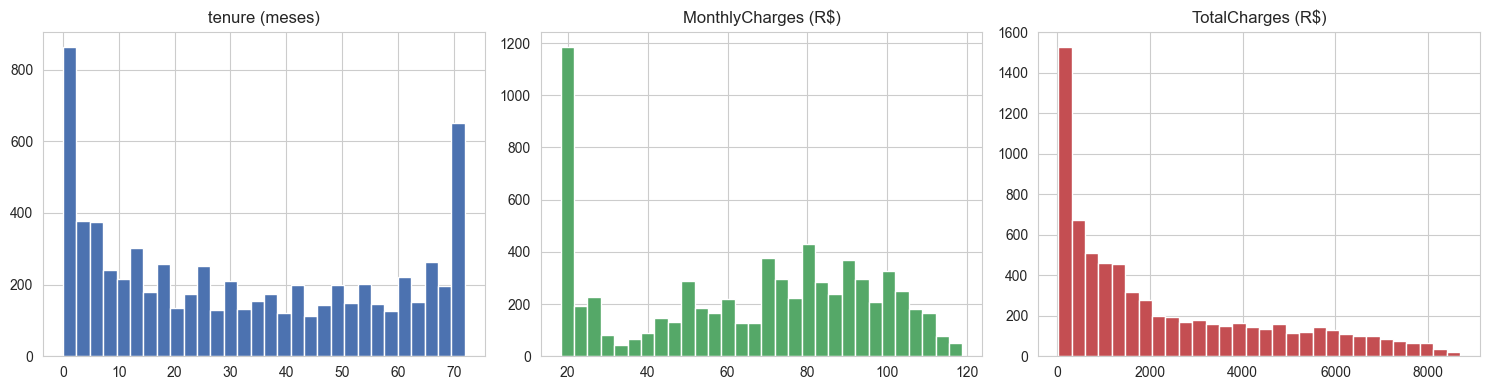

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df["tenure"].hist(bins=30, ax=axes[0], color="#4C72B0")
axes[0].set_title("tenure (meses)")
df["MonthlyCharges"].hist(bins=30, ax=axes[1], color="#55A868")
axes[1].set_title("MonthlyCharges (R$)")
df["TotalCharges"].dropna().hist(bins=30, ax=axes[2], color="#C44E52")
axes[2].set_title("TotalCharges (R$)")
plt.tight_layout()
plt.show()

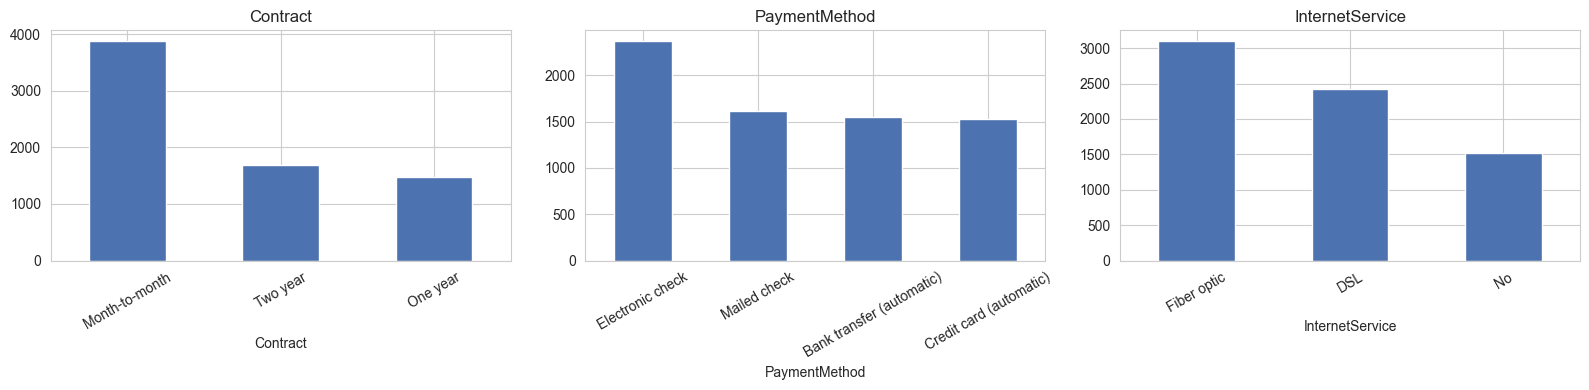

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["Contract", "PaymentMethod", "InternetService"]):
    df[col].value_counts().plot(kind="bar", ax=ax, color="#4C72B0")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

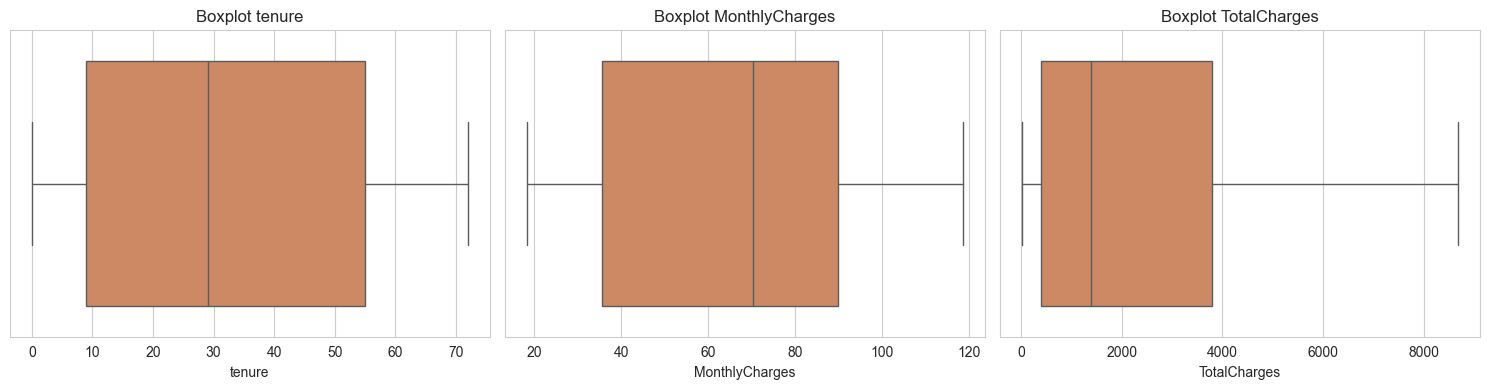

→ TotalCharges com cauda longa esperada (LTV cumulativo).


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.boxplot(x=df[col], ax=ax, color="#DD8452")
    ax.set_title(f"Boxplot {col}")
plt.tight_layout()
plt.show()
print("→ TotalCharges com cauda longa esperada (LTV cumulativo).")

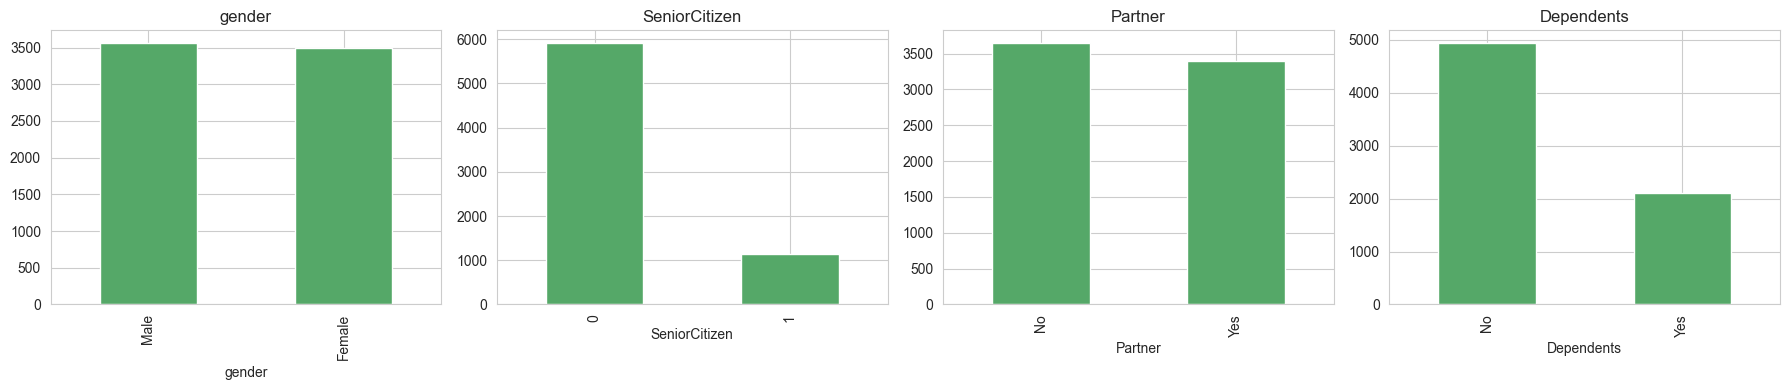

In [14]:
# Categóricas binárias demográficas
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, ["gender", "SeniorCitizen", "Partner", "Dependents"]):
    df[col].value_counts().plot(kind="bar", ax=ax, color="#55A868")
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [15]:
# Distribuição de serviços (proporção por categoria)
service_cols = ["PhoneService", "MultipleLines", "OnlineSecurity",
                "OnlineBackup", "DeviceProtection", "TechSupport",
                "StreamingTV", "StreamingMovies"]
df[service_cols].apply(lambda s: s.value_counts(normalize=True).round(2)).T

,No,No internet service,No phone service,Yes
PhoneService,0.10,NaN,NaN,0.90
MultipleLines,0.48,NaN,0.1,0.42
OnlineSecurity,0.50,0.22,NaN,0.29
OnlineBackup,0.44,0.22,NaN,0.34
DeviceProtection,0.44,0.22,NaN,0.34
TechSupport,0.49,0.22,NaN,0.29
StreamingTV,0.40,0.22,NaN,0.38
StreamingMovies,0.40,0.22,NaN,0.39


## 6. Patterns de churn por segmento

Cruzamentos da target com features-chave. Esperamos:

- Contract `Month-to-month` com churn muito mais alto que `Two year`.
- Clientes novos (`tenure ≤ 12`) com churn maior.
- `MonthlyCharges` no quartil superior associado a churn maior.
- `Electronic check` como método de pagamento associado a churn maior.

In [16]:
churn_by_contract = (df.assign(churn_bin=(df["Churn"] == "Yes").astype(int))
                       .groupby("Contract")["churn_bin"].agg(["mean", "count"]))
churn_by_contract.columns = ["churn_rate", "n"]
churn_by_contract["churn_rate"] = (churn_by_contract["churn_rate"] * 100).round(2)
churn_by_contract.sort_values("churn_rate", ascending=False)

,churn_rate,n
Contract,,
Month-to-month,42.71,3875
One year,11.27,1473
Two year,2.83,1695


In [17]:
df["tenure_bracket"] = pd.cut(df["tenure"], bins=[-1, 12, 24, 48, 72],
                              labels=["0-12", "13-24", "25-48", "49-72"])
churn_by_tenure = (df.assign(churn_bin=(df["Churn"] == "Yes").astype(int))
                     .groupby("tenure_bracket", observed=True)["churn_bin"]
                     .agg(["mean", "count"]))
churn_by_tenure.columns = ["churn_rate", "n"]
churn_by_tenure["churn_rate"] = (churn_by_tenure["churn_rate"] * 100).round(2)
churn_by_tenure

,churn_rate,n
tenure_bracket,,
0-12,47.44,2186
13-24,28.71,1024
25-48,20.39,1594
49-72,9.51,2239


In [18]:
df["mc_quartile"] = pd.qcut(df["MonthlyCharges"], q=4,
                            labels=["Q1", "Q2", "Q3", "Q4"])
churn_by_mc = (df.assign(churn_bin=(df["Churn"] == "Yes").astype(int))
                 .groupby("mc_quartile", observed=True)["churn_bin"]
                 .agg(["mean", "count"]))
churn_by_mc.columns = ["churn_rate", "n"]
churn_by_mc["churn_rate"] = (churn_by_mc["churn_rate"] * 100).round(2)

churn_by_pay = (df.assign(churn_bin=(df["Churn"] == "Yes").astype(int))
                  .groupby("PaymentMethod")["churn_bin"]
                  .agg(["mean", "count"]))
churn_by_pay.columns = ["churn_rate", "n"]
churn_by_pay["churn_rate"] = (churn_by_pay["churn_rate"] * 100).round(2)

print("=== Churn por quartil MonthlyCharges ===")
display(churn_by_mc)
print("\n=== Churn por PaymentMethod ===")
display(churn_by_pay.sort_values("churn_rate", ascending=False))

=== Churn por quartil MonthlyCharges ===


,churn_rate,n
mc_quartile,,
Q1,11.24,1762
Q2,24.58,1766
Q3,37.51,1757
Q4,32.88,1758



=== Churn por PaymentMethod ===


,churn_rate,n
PaymentMethod,,
Electronic check,45.29,2365
Mailed check,19.11,1612
Bank transfer (automatic),16.71,1544
Credit card (automatic),15.24,1522


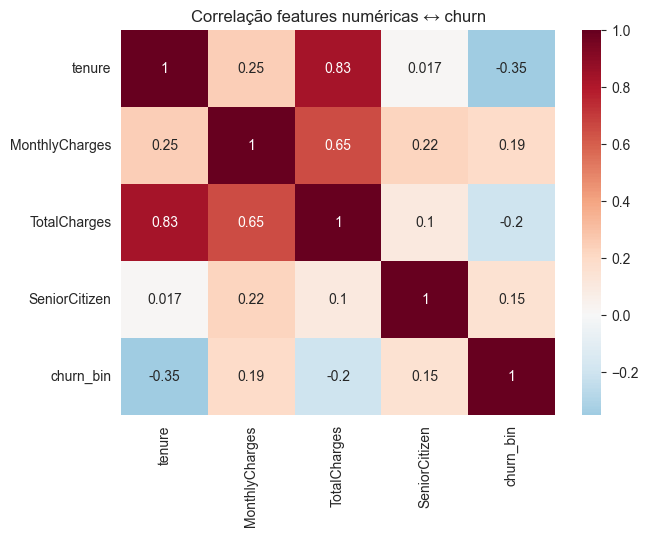

In [19]:
# Correlação numéricas vs target
df_num = df.copy()
df_num["churn_bin"] = (df_num["Churn"] == "Yes").astype(int)
corr_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "churn_bin"]
corr = df_num[corr_cols].corr().round(3)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Correlação features numéricas ↔ churn")
plt.show()

## 7. Conclusões e *data readiness*

### Achados principais

1. **Volume:** 7.043 linhas × 21 colunas → suficiente para classificação binária tabular clássica.
2. **Qualidade:** `TotalCharges` requer coerção `to_numeric` (≈ 11 linhas ficam NaN — clientes com `tenure=0`); `No internet/phone service` deve ser mapeado para `No` antes do encoding.
3. **Target:** ~26.5% positivos → desbalanceado, justifica `class_weight='balanced'` e métrica primária *recall*.
4. **Sinal forte:** Contract `Month-to-month`, clientes novos (`tenure ≤ 12`), `Electronic check` como pagamento e quartil 4 de `MonthlyCharges` concentram maior churn.
5. **Outliers:** `TotalCharges` com cauda longa esperada (não é outlier real, é função de tenure × MonthlyCharges).

### Achados → Ações para Feature Engineering (Etapa 2)

1. **Coerção de tipo:** `TotalCharges` → `float` antes do split. ✓ já implementado em [`Baseline.coerce_object_columns_to_numeric`](../src/services/pipelines/baseline.py).
2. **Mapeamento Yes/No/Sub-categorias:** `No internet service` → 0, `No phone service` → 0. ✓ já implementado em [`Baseline.pre_processor_churn`](../src/services/pipelines/baseline.py).
3. **Feature derivada `contract_stability`:** binário 1 se `Contract ≠ Month-to-month`. ✓ implementado em [`ChurnFeatures`](../src/services/pipelines/feature_strategies/churn_features.py).
4. **Feature derivada `is_new_customer`:** binário 1 se `tenure ≤ 12`. ✓ idem.
5. **Feature derivada `tenure_log`:** `log1p(tenure)` para reduzir cauda. ✓ idem.
6. **Feature derivada `charge_ratio`:** `MonthlyCharges / (TotalCharges + 1)` para detectar cobrança recente. ✓ idem.
7. **Feature derivada `risk_payment_monthly`:** binário 1 se `PaymentMethod=Electronic check` e `Contract=Month-to-month`. ✓ idem.

A coerência entre EDA e implementação valida o `ChurnFeatures` strategy.

### Checklist de *data readiness*

- [x] Volume suficiente (≥ 5.000 linhas pelo PDF).
- [x] Schema documentado (21 colunas, dtypes mapeados).
- [x] Qualidade auditada (`TotalCharges` coerção, mapeamentos categóricos).
- [x] Target balanceado o suficiente para `class_weight='balanced'`.
- [x] Sinal preditivo identificado (Contract, tenure, PaymentMethod, MonthlyCharges).
- [x] Sem leakage óbvio (todas as features são pré-evento de cancelamento).
- [x] Sem PII além de `customerID` (será removida pelo pipeline).

→ Dataset *ready* para baseline + feature engineering + MLP.